In [5]:
import fontTools.fontBuilder
import pandas as pd
import numpy as np
import matplotlib.pyplot as pt

## To remove warnings
import os
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["LOKY_MAX_CPU_COUNT"] = "8"   # or your logical core count
import warnings
warnings.filterwarnings("ignore")
from networkx.classes import non_neighbors

names = ['existingchecking', 'duration', 'credithistory', 'purpose', 'creditamount',
         'savings', 'employmentsince', 'installmentrate', 'statussex', 'otherdebtors',
         'residencesince', 'property', 'age', 'otherinstallmentplans', 'housing',
         'existingcredits', 'job', 'peopleliable', 'telephone', 'foreignworker', 'classification']

customers = pd.read_csv('../../Potomac/AIT 620/LabWorks/PythonProject/datafiles/german.data', names=names, delimiter=' ')

customers.head()


,existingchecking,duration,credithistory,purpose,creditamount,savings,employmentsince,installmentrate,statussex,otherdebtors,...,property,age,otherinstallmentplans,housing,existingcredits,job,peopleliable,telephone,foreignworker,classification
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,2


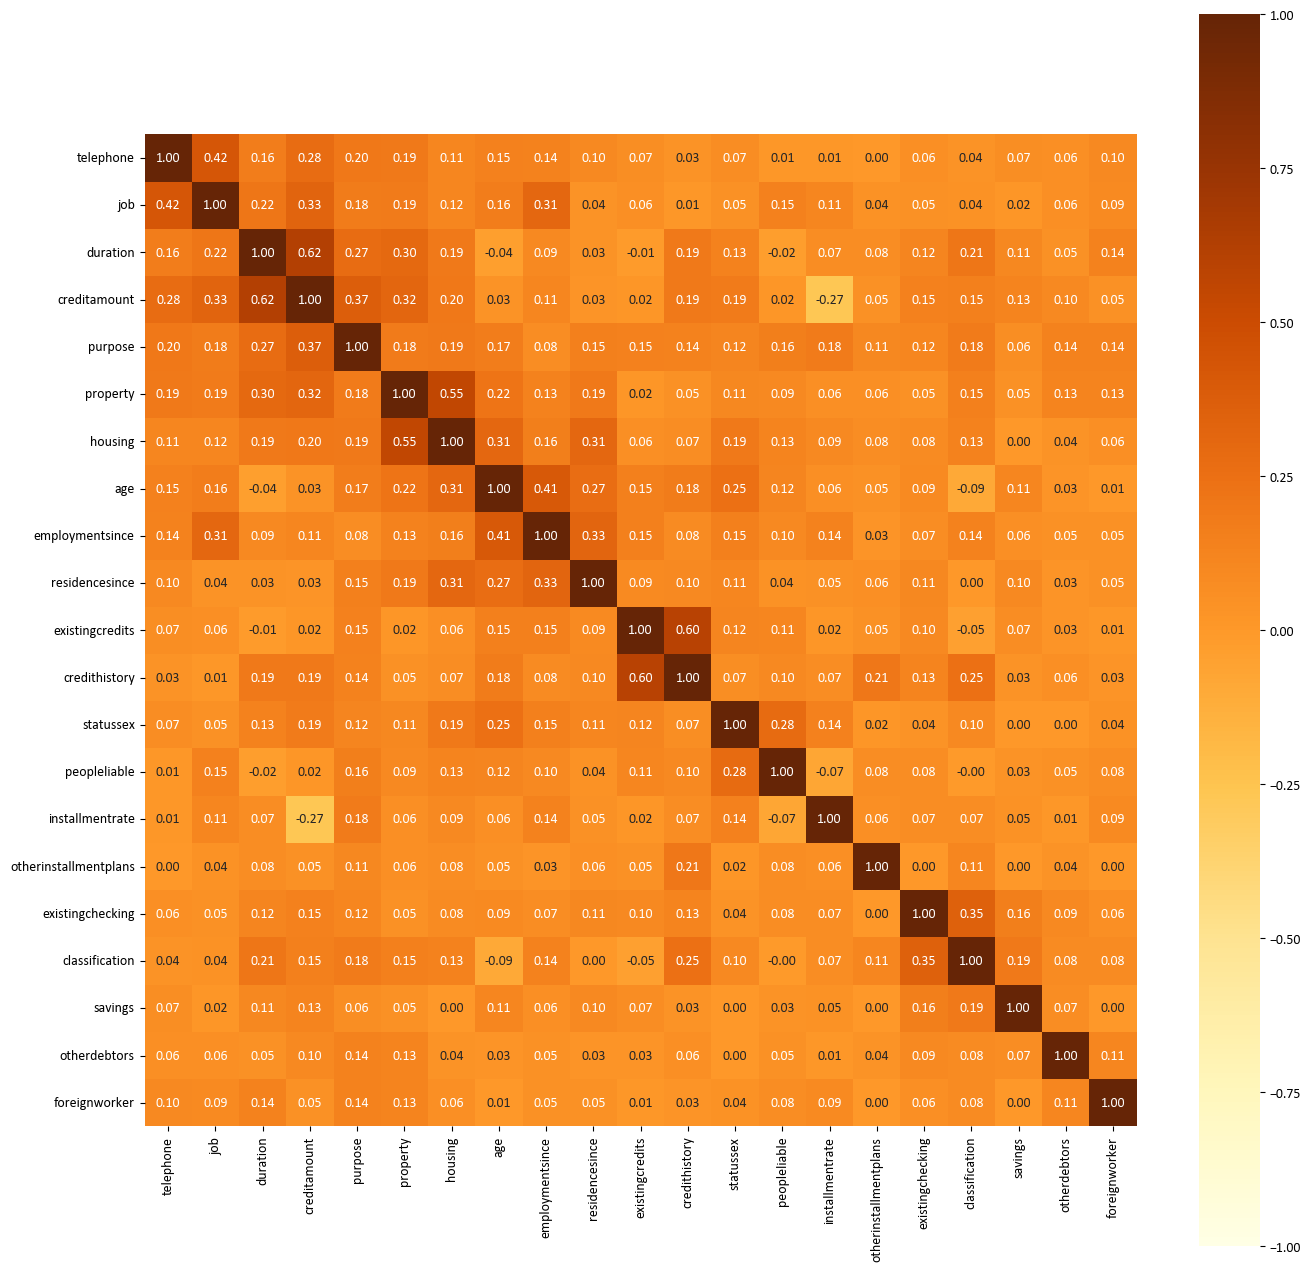

,creditamount,duration,installmentrate,residencesince,age,existingcredits,peopleliable,classification,existingchecking_A11,existingchecking_A12,...,housing_A152,housing_A153,job_A171,job_A172,job_A173,job_A174,telephone_A191,telephone_A192,foreignworker_A201,foreignworker_A202
0,1169,6,4,4,67,2,1,1,True,False,...,True,False,False,False,True,False,False,True,True,False
1,5951,48,2,2,22,1,1,2,False,True,...,True,False,False,False,True,False,True,False,True,False
2,2096,12,2,3,49,1,2,1,False,False,...,True,False,False,True,False,False,True,False,True,False
3,7882,42,2,4,45,1,2,1,True,False,...,False,True,False,False,True,False,True,False,True,False
4,4870,24,3,4,53,2,2,2,True,False,...,False,True,False,False,True,False,True,False,True,False


In [17]:
from dython.nominal import associations
#fig = pt.figure(figsize=(16, 16))

pt.rcParams['font.family'] = 'Calibri'  # Example: use serif font family
pt.rcParams['font.size'] = 10         # Example: set default font size to 12

result = associations(customers, clustering=True, figsize=(16, 16),cmap='YlOrBr')
# Adjust tick label fonts

# Step 2 — get the axes AFTER associations() draws

pt.show()

catvars = ['existingchecking', 'credithistory', 'purpose', 'savings', 'employmentsince',
           'statussex', 'otherdebtors', 'property', 'otherinstallmentplans', 'housing', 'job',
           'telephone', 'foreignworker']
numvars = ['creditamount', 'duration', 'installmentrate', 'residencesince', 'age',
           'existingcredits', 'peopleliable', 'classification']

dummyvars = pd.get_dummies(customers[catvars])
transactions = pd.concat([customers[numvars], dummyvars], axis = 1)

transactions.head()

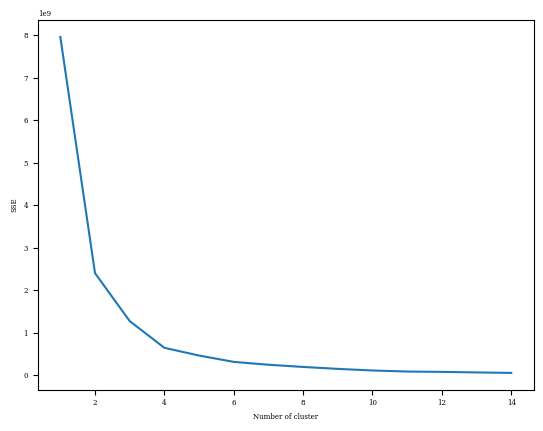

,age_mean,age_std,creditamount,duration,count,class_mean,class_std
cluster,,,,,,,
0,35.631193,11.672843,1473.267890,15.099083,545,1.273394,0.446111
2,34.635088,10.738251,3603.540351,23.621053,285,1.277193,0.448400
1,36.798450,11.255124,7175.837209,33.232558,129,1.364341,0.483121
3,36.804878,11.914738,12576.463415,40.365854,41,1.609756,0.493865


In [8]:
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
sse = {}
for k in range(1, 15):
    kmeans = (KMeans(n_clusters=k))
    kmeans.fit(transactions)
    sse[k] = kmeans.inertia_

plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.ylabel("SSE")
plt.show()
kmeans =(KMeans(n_clusters=4)).fit(transactions)
y = kmeans.labels_

clusters = (transactions.join(pd.DataFrame(data=y, columns=['cluster'])).
            groupby('cluster')
            .agg(
                age_mean=pd.NamedAgg(column='age', aggfunc='mean'),
                age_std=pd.NamedAgg(column='age', aggfunc='std'),
                creditamount=pd.NamedAgg(column='creditamount',aggfunc='mean'),
                duration=pd.NamedAgg(column='duration', aggfunc='mean'),
                count=pd.NamedAgg(column='age', aggfunc='count'),
                class_mean=pd.NamedAgg(column='classification', aggfunc='mean'),
                class_std=pd.NamedAgg(column='classification',aggfunc='std'),
            ).sort_values(by='class_mean'))
clusters

In [9]:
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering

# Compute pairwise distances on scaled features
distances = squareform(
    pdist(
        StandardScaler().fit_transform(
            transactions[['classification', 'creditamount', 'duration']]
        )
    )
)

# Perform agglomerative clustering using the precomputed distance matrix
clustering = AgglomerativeClustering(
    n_clusters=5,
    metric='precomputed',
    linkage='average'
).fit(distances)

# Extract cluster labels
y = clustering.labels_

clusters = (
    transactions
        .join(pd.DataFrame(data=y, columns=['cluster']))
        .groupby(by='cluster')
        .agg(
            age_mean=pd.NamedAgg(column='age', aggfunc='mean'),
            age_std=pd.NamedAgg(column='age', aggfunc='std'),
            creditamount=pd.NamedAgg(column='creditamount', aggfunc='mean'),
            duration=pd.NamedAgg(column='duration', aggfunc='mean'),
            count=pd.NamedAgg(column='age', aggfunc='count'),
            class_mean=pd.NamedAgg(column='classification', aggfunc='mean'),
            class_std=pd.NamedAgg(column='classification', aggfunc='std'),
        )
        .sort_values(by='class_mean')
)

clusters

,age_mean,age_std,creditamount,duration,count,class_mean,class_std
cluster,,,,,,,
4,35.920000,7.348025,8289.740000,42.640000,50,1.000000,0.000000
2,35.548165,11.489624,2473.405963,17.779817,872,1.259174,0.438433
0,38.200000,16.457352,15271.600000,51.300000,10,1.600000,0.516398
1,34.530303,10.989813,7845.363636,41.545455,66,2.000000,0.000000
3,45.500000,31.819805,14725.500000,6.000000,2,2.000000,0.000000


In [10]:
import jax.numpy as jnp
import numpy as np

from jax import jit, vmap
from sklearn.base import ClassifierMixin

import jax
import random

from scipy.stats import hmean

class KMeans(ClassifierMixin):

    def __init__(self, k, n_iter=100):
        self.k = k
        self.n_iter = n_iter

        # JIT‑compiled batched Euclidean distance
        self.euclidean = jit(
            vmap(
                lambda x, y: jnp.linalg.norm(
                    x - y, ord=2, axis=-1, keepdims=False
                ),
                in_axes=(0, None),
                out_axes=0
            )
        )

    # def adjust_centers(self, X):
    #     return jnp.row_stack([
    #         X[self.clusters == c].mean(axis=0)
    #         for c in self.clusters
    #     ])

    def adjust_centers(self, X):
        return jnp.vstack([
            X[self.clusters == c].mean(axis=0)
            for c in range(self.k)
        ])

    def initialize_centers(self):
        """
        Roughly the k-means++ initialization
        """
        key = jax.random.PRNGKey(0)

        # JAX doesn't have uniform_multivariate
        self.centers = jax.random.multivariate_normal(
            key,
            jnp.mean(X, axis=0),
            jnp.cov(X, rowvar=False),
            shape=(1,)
        )

        for c in range(1, self.k):
            weights = self.euclidean(X, self.centers)

            if c > 1:
                weights = hmean(weights, axis=-1)
                print(weights.shape)

            # new_center = jnp.array(
            #     random.choices(X, weights=weights, k=1)[0],
            #     ndmin=2
            # )
            weights = self.euclidean(X, self.centers)  # shape (n_samples, n_centers)

            # Reduce to 1-D: distance to nearest center
            weights = weights.min(axis=1)

            # Convert distances to probabilities (invert so far points get higher weight)
            weights = 1 / (weights + 1e-8)

            # Normalize
            weights = weights / weights.sum()

            # Sample index
            idx = np.random.choice(len(X), p=np.array(weights))
            new_center = X[idx:idx + 1]

            self.centers = jnp.vstack((self.centers, new_center))
            print(self.centers.shape)

    def fit(self, X, y=None):
        self.initialize_centers()

        for iter in range(self.n_iter):
            dists = self.euclidean(X, self.centers)
            self.clusters = jnp.argmin(dists, axis=-1)
            self.centers = self.adjust_centers(X)


        return self.clusters

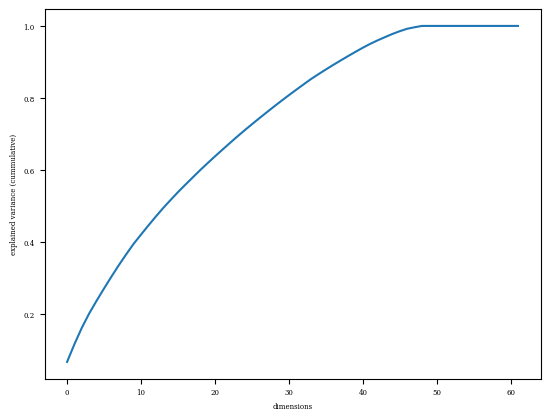

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, FastICA
import matplotlib.pyplot as plt

pca = PCA().fit(
    StandardScaler().fit_transform(transactions)
)
ax = plt.plot(
    range(len(pca.explained_variance_ratio_)),
    np.cumsum(pca.explained_variance_ratio_)
)
plt.ylabel('explained variance (cummulative)')
plt.xlabel('dimensions')
plt.show()



In [13]:
len(transactions.columns)

62

In [14]:
transactions.columns

Index(['creditamount', 'duration', 'installmentrate', 'residencesince', 'age',
       'existingcredits', 'peopleliable', 'classification',
       'existingchecking_A11', 'existingchecking_A12', 'existingchecking_A13',
       'existingchecking_A14', 'credithistory_A30', 'credithistory_A31',
       'credithistory_A32', 'credithistory_A33', 'credithistory_A34',
       'purpose_A40', 'purpose_A41', 'purpose_A410', 'purpose_A42',
       'purpose_A43', 'purpose_A44', 'purpose_A45', 'purpose_A46',
       'purpose_A48', 'purpose_A49', 'savings_A61', 'savings_A62',
       'savings_A63', 'savings_A64', 'savings_A65', 'employmentsince_A71',
       'employmentsince_A72', 'employmentsince_A73', 'employmentsince_A74',
       'employmentsince_A75', 'statussex_A91', 'statussex_A92',
       'statussex_A93', 'statussex_A94', 'otherdebtors_A101',
       'otherdebtors_A102', 'otherdebtors_A103', 'property_A121',
       'property_A122', 'property_A123', 'property_A124',
       'otherinstallmentplans_A141',

In [15]:
from sklearn.manifold import LocallyLinearEmbedding
import numpy as np

dimensions_range = [1, 11]   # n_components = 1..10
n_neighbors = 10             # must be >= max n_components

reconstruction_errors = np.zeros(dimensions_range[1])

for n_components in range(*dimensions_range):

    lle = LocallyLinearEmbedding(
        n_components=n_components,
        n_neighbors=n_neighbors,
        n_jobs=-1,
        method='standard'
    ).fit(transactions)

    # LLE always provides the barycentric weight matrix

    error = lle.reconstruction_error_
    reconstruction_errors[n_components] = error
print("Reconstruction errors:", reconstruction_errors[1:11])

Reconstruction errors: [9.60310428e-11 6.99560259e-09 2.13892850e-08 7.59813195e-08
 2.09924977e-07 4.51334297e-07 1.04707349e-06 1.91063371e-06
 3.45998696e-06 5.69324003e-06]
